# Variational Autoencoders

- Get MNIST Numbers
- First get warmed up with a convolutional autoencoder
- Then a few VAEs - Start with unconditional based on FC nets
- Then a conditional VAE
- And then a conditional convolutional VAE

In [1]:
#Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#PyTorch Libraries
import torch
import torch.nn as nn
import torchvision

import torchvision.transforms.v2 as transforms

from torch.utils.data import Dataset, DataLoader


In [2]:
## We will use a GPU if possible
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

device

device(type='cpu')

## MNIST Numbers

Simple "Hello World" dataset for machine learning

In [3]:
## We'll get the MNIST dataset from torchvision.datasets

from torchvision.datasets import MNIST

#Also, we'll want to transform ToTensor:
from torchvision.transforms import ToTensor

#Get the train and test sets:
#######

mnist_trainset = MNIST(root='./', train=True, download=True, transform=ToTensor())

mnist_testset = MNIST(root='./', train=False, download=True, transform=ToTensor())

In [4]:
## Let's use Subset from torch.utils.data to get a validation set:
########

from torch.utils.data import Subset

indices1 = range(0, int(55e3), 1)
indices2 = range(int(55e3), int(60e3), 1)

mnist_train = Subset(mnist_trainset, indices1)
mnist_valid = Subset(mnist_trainset, indices2)


In [5]:
#Put into a DataLoader:

train_loader = DataLoader(mnist_train, batch_size=32, shuffle=True)
valid_loader = DataLoader(mnist_valid, batch_size=32, shuffle=False)

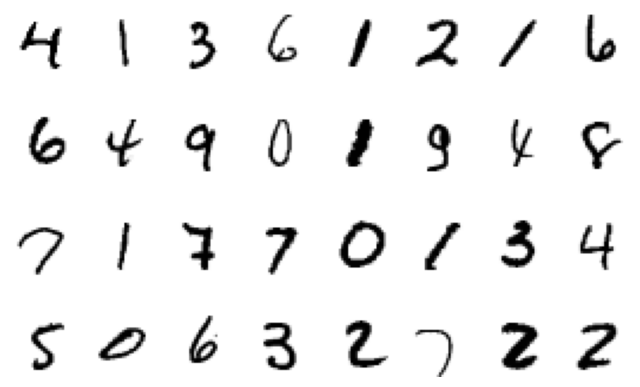

In [6]:
#Plot some examples:
######

fig1, ax1 = plt.subplots(4, 8, figsize=(8,5))

#Flatten for easier indexing
ax1 = ax1.flatten()

X, y = next(iter(train_loader))

#And plot:
for i in range(32):

    im = ax1[i].imshow(X[i].numpy().squeeze(), cmap='gray_r')
    ax1[i].set_axis_off()


## A Simple Convolutional Autoencoder

- Include bookkeeping needed to use a GPU

In [7]:
#Encoder:
#######

class ConvEncoder(nn.Module):
    def __init__(self):

        super().__init__()

        self.conv1 = nn.Conv2d(1, 16, (3,3), stride=1, padding='same')
        self.bn1 = nn.BatchNorm2d(16)
        self.pool1 = nn.MaxPool2d(2, 2) #Will reduce size to 14x14

        self.conv2 = nn.Conv2d(16, 32, (3,3), stride=1, padding='same')
        self.bn2 = nn.BatchNorm2d(32)
        self.pool2 = nn.MaxPool2d(2, 2) #Reduce size to 7x7

        self.conv3 = nn.Conv2d(32, 64, (3,3), stride=1, padding='same')
        self.bn3 = nn.BatchNorm2d(64)
        self.pool3 = nn.MaxPool2d(2, 2) #Reduce to 3x3

        self.linear = nn.Linear(3*3*64, 64)

        self.relu = nn.ReLU()


    def forward(self, x):
        x = self.pool1(self.relu(self.bn1(self.conv1(x))))
        x = self.pool2(self.relu(self.bn2(self.conv2(x))))
        x = self.pool3(self.relu(self.bn3(self.conv3(x))))

        x = x.view(-1, 3*3*64)
        x = self.linear(x)


        return x


In [8]:
## And Decoder:
#####

class ConvDecoder(nn.Module):
    def __init__(self):

        super().__init__()

        self.layer0 = nn.Linear(64, 3*3*64)

        self.convT1 = nn.ConvTranspose2d(64, 32, (3,3), stride=2, padding=0) #, output_padding=1)
        self.bn1 = nn.BatchNorm2d(32)

        self.convT2 = nn.ConvTranspose2d(32, 16, (3,3), stride=2, padding=1, output_padding=1)
        self.bn2 = nn.BatchNorm2d(16)

        self.convT3 = nn.ConvTranspose2d(16, 1, (3,3), stride=2, padding=1, output_padding=1)
        self.bn3 = nn.BatchNorm2d(1)

        self.sigmoid = nn.Sigmoid()
        self.relu = nn.ReLU()

    def forward(self, x):

        x = (self.layer0(x)).view(-1, 64, 3, 3)

        x = self.relu(self.bn1(self.convT1(x)))
        x = self.relu(self.bn2(self.convT2(x)))
        x = self.sigmoid(self.bn3(self.convT3(x)))

        return x

In [9]:
#Make:
####

conv_encoder = ConvEncoder()
conv_decoder = ConvDecoder()

#Combine:
conv_autoencoder = nn.Sequential(conv_encoder, conv_decoder)

#To device:
conv_autoencoder = conv_autoencoder.to(device)

In [10]:
## Let's train:

#Loss Function:
loss_function = nn.MSELoss()

#And Optimizer:
optimizer = torch.optim.Adam(conv_autoencoder.parameters(), lr=0.005)


In [13]:
batch = next(iter(train_loader))
X_in, y = batch

X_in.shape

#z = conv_encoder(X_in)

#conv_decoder(z).shape

torch.Size([32, 1, 28, 28])

In [14]:
## Run the training loop for a number of epochs
loss_list = []

conv_autoencoder.train()

for epoch in range(1):

    for batch in train_loader:
        #Unpack to X and y
        X_in, y = batch

        X_in = X_in.to(device)
        y = y.to(device)

        #X_in = X_in.flatten(1)

        #Train on our input:
        X_out = conv_autoencoder(X_in)

        #Loss:
        loss = loss_function(X_out, X_in)

        #Backprop
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        loss_list.append(loss.item())

    print(epoch)
    print(loss.item())

0
0.008971956558525562


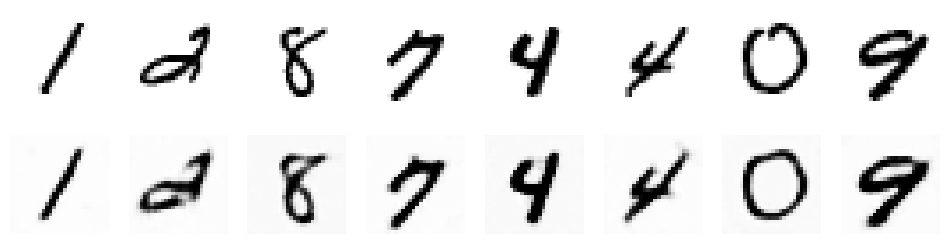

In [15]:
#### Plot outputs of autoencoder:
#########
fig1, ax1 = plt.subplots(2, 8, figsize=(12,3))

#Note: Try
X, y = next(iter(valid_loader))

#And plot:
for i in range(8):

    im = ax1[0, i].imshow(X[i].permute(1,2,0), cmap='gray_r')
    ax1[0, i].set_axis_off()

    #And reconstruction:
    conv_autoencoder.eval()

    with torch.no_grad():
        image = conv_autoencoder(X[i].unsqueeze(0).to(device)).squeeze(0).cpu()

    #Can clip to 0, 1:
    #image = np.clip(image, 0, 1)

    ax1[1, i].imshow(image.permute(1,2,0), cmap='gray_r')
    ax1[1, i].set_axis_off()

## Minimal Variational AE

- Let's make a VAE using a FC architecture
- We'll convert to convolutional after

In [16]:
## Make a class with the following:
# - __init__ method that sets up our Encoder and Decoder
# - An encode object Q(Z | X) that takes input X and returns a vector of means and a vector of gamma = log(var)
# [ Note sigma = exp(.5 gamma) ]
# - sample_z method that samples from the latent space using the given means and gammas (gives us a Z)
# - decode object that takes Z and returns a generated sample P(X | Z)
# - forward method that takes X as input, runs encode Q(Z | X), samples Z based on means/gammas, runs decode P(X | Z)
# When in inference, just call VAE.decode(Z = N(0,1))


In [17]:
## First define the Encoder separately:
###

class VAE_Encoder(nn.Module):

    def __init__(self, input_dim, z_dim):
        super().__init__()

        self.linear1 = nn.Linear(input_dim, 128)
        self.linear2 = nn.Linear(128, 64)
        self.linear3 = nn.Linear(64, z_dim * 2)

        self.relu = nn.ReLU()

    def forward(self, x):

        #Run the encoder, get 2*z_dim = 1 vector for means, 1 vector for gamma = log(var)
        x = self.relu(self.linear1(x))
        x = self.relu(self.linear2(x))
        x = self.linear3(x)

        return x


In [18]:
class VAE_Decoder(nn.Module):

    def __init__(self, z_dim, output_dim):
        super().__init__()

        self.linear1 = nn.Linear(z_dim, 64)
        self.linear2 = nn.Linear(64, 128)
        self.linear3 = nn.Linear(128, output_dim)

        self.relu = nn.ReLU()

    def forward(self, z):

        #Run the decoder given z
        z = self.relu(self.linear1(z))
        z = self.relu(self.linear2(z))
        z = self.linear3(z)

        return z


In [19]:
class MyVAE(nn.Module):

    def __init__(self, input_dim, z_dim):

        super().__init__()

        #Create the encoder
        self.encoder = VAE_Encoder(input_dim, z_dim)
        self.decoder = VAE_Decoder(z_dim, input_dim)

    #z_mean = mean vector, z_gamma = logvar vector
    def get_z_sample(self, z_mean, z_gamma):

        #Draw from a standard normal
        epsilon = torch.randn_like(z_mean)

        #Standard deviation
        sigma = torch.exp(.5 * z_gamma)

        #Latent sample:
        Z = z_mean + epsilon * sigma
        return Z


    #Run the model in training mode:
    def forward(self, x):

        #First encode:
        mu_gamma = self.encoder(x)

        #split and pass to get_z_sample:
        mu, gamma = mu_gamma.chunk(2, axis=-1)

        #Sample:
        z = self.get_z_sample(mu, gamma)

        #Finally decode:
        x_out = self.decoder(z)

        #Return the x_out, mu, and gamma:
        return x_out, mu, gamma


In [24]:
## Check:

z_dim=64
vae = MyVAE(input_dim=28*28*1, z_dim=z_dim)

vae = vae.to(device)

#x = torch.rand((1,28,28)).unsqueeze(0)

#vae(x.flatten())

In [25]:
#Reconstruction loss Function:
recon_loss = nn.MSELoss()

#And Optimizer:
optimizer = torch.optim.Adam(vae.parameters(), lr=0.001)

In [36]:
## Run the training loop for a number of epochs
loss_list = []

vae.train()

for epoch in range(1):

    for batch in train_loader:
        #Unpack to X and y
        X_in, y = batch

        X_in = X_in.to(device)
        y = y.to(device)

        X_in = X_in.flatten(1)

        #Train on our input:
        X_out, mu, gamma = vae(X_in)

        #Loss:
        #Combo of KL divergence and MSE:
        sigma2 = torch.exp(gamma) #gamma = log(sigma2) so just use gamma in one term below:

        KL_loss = torch.mean(-.5 * torch.sum(1 + gamma - sigma2 - mu**2, axis=-1)) #Mean across the batch

        loss = recon_loss(X_out, X_in) + 1 * KL_loss / 784 #Divide by 784 = number of pixels

        #Backprop
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        loss_list.append(loss.item())

    print(epoch)
    print(loss.item())

0
0.0478011853992939


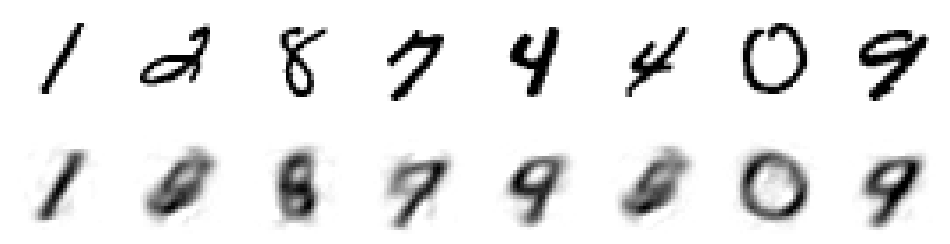

In [37]:
#### Plot outputs of autoencoder:
#########
fig1, ax1 = plt.subplots(2, 8, figsize=(12,3))

#Note: Try
X, y = next(iter(valid_loader))

#And plot:
for i in range(8):

    im = ax1[0, i].imshow(X[i].permute(1,2,0), cmap='gray_r')
    ax1[0, i].set_axis_off()

    #And reconstruction:
    vae.eval()

    with torch.no_grad():
        image = vae(X[i].flatten().unsqueeze(0).to(device))[0].squeeze(0).view(1,28,28).cpu()

    #Can clip to 0, 1:
    image = np.clip(image, 0, 1)

    ax1[1, i].imshow(image.permute(1,2,0), cmap='gray_r')
    ax1[1, i].set_axis_off()

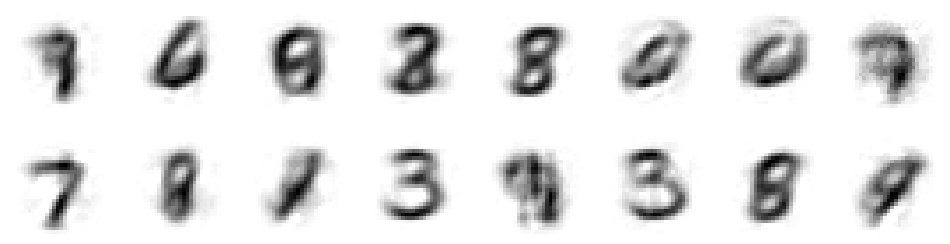

In [38]:
#### Do inference sampling:
#########
fig1, ax1 = plt.subplots(2, 8, figsize=(12,3))
ax1 = ax1.flatten()

vae.eval()

for i in range(16):

    with torch.no_grad():
        Z = torch.randn(z_dim)
        image = vae.decoder(Z.to(device)).view(1,28,28).cpu()

    #Can clip to 0, 1:
    image = np.clip(image, 0, 1)

    ax1[i].imshow(image.permute(1,2,0), cmap='gray_r')
    ax1[i].set_axis_off()

## Now condition on class

In [39]:
class ConditionalVAE(nn.Module):

    def __init__(self, input_dim, num_classes, z_dim):

        super().__init__()

        self.num_classes = num_classes

        #Create the encoder: Note additional num_classes for dimensions
        self.encoder = VAE_Encoder(input_dim + num_classes, z_dim)
        self.decoder = VAE_Decoder(z_dim + num_classes, input_dim)

    #z_mean = mean vector, z_gamma = logvar vector
    def get_z_sample(self, z_mean, z_gamma):

        #Draw from a standard normal
        epsilon = torch.randn_like(z_mean)

        #Standard deviation
        sigma = torch.exp(.5 * z_gamma)

        #Latent sample:
        Z = z_mean + epsilon * sigma
        return Z


    #Run the model in training mode:
    def forward(self, x):

        #Expects last num_classes columns to be one-hot class vectors

        #First encode:
        mu_gamma = self.encoder(x)

        #split and pass to get_z_sample:
        mu, gamma = mu_gamma.chunk(2, axis=-1)

        #Sample:
        z = self.get_z_sample(mu, gamma)

        #Add class one-hot vector
        z = torch.cat((z, x[:,-self.num_classes:]), dim=-1)

        #Finally decode:
        x_out = self.decoder(z)

        #Return the x_out, mu, and gamma:
        return x_out, mu, gamma


In [40]:
## Simple conditional VAE
########

# We'll use the exact same model, but will concat input with one-hot encoded class vector

z_dim=32
class_vae = ConditionalVAE(input_dim=28*28*1, num_classes=10, z_dim=z_dim)

class_vae = class_vae.to(device)

In [41]:
#Reconstruction loss Function:
recon_loss = nn.MSELoss()

#And Optimizer:
optimizer = torch.optim.Adam(class_vae.parameters(), lr=0.001)

In [42]:
#Check input:

X_in, y = next(iter(train_loader))

X_in = X_in.flatten(1)

X_in.shape

torch.Size([32, 784])

In [47]:
#Add one-hot encoding of digit class:

y_one_hot = torch.nn.functional.one_hot(y, 10)
x = torch.cat((X_in, y_one_hot), axis=-1)

x.shape

x[:,-10:]

tensor([[0., 0., 0., 1., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 1., 0., 0., 0.],
        [0., 0., 1., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
        [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 1., 0., 0., 0., 0., 0.],
        [0., 0., 0., 1., 0., 0., 0., 0., 0., 0.],
        [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 1., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 1., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
        [0., 0., 0., 0., 0., 1., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 1., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 1., 0.],
        [0., 0., 0., 0., 0., 0., 1., 0., 0., 0.],
        [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
        [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 1., 0., 0.],
        [0., 0., 1., 0., 0., 0., 0., 0., 0., 0.],


In [50]:
## Run the training loop for a number of epochs
loss_list = []

class_vae.train()

for epoch in range(1):

    for batch in train_loader:
        #Unpack to X and y
        X_in, y = batch

        X_in = X_in.to(device)
        y = y.to(device)

        X_in = X_in.flatten(1)

        y_one_hot = torch.nn.functional.one_hot(y, 10) #Add one-hot classes to input
        X_in = torch.cat((X_in, y_one_hot), axis=-1)

        #Train on our input:
        X_out, mu, gamma = class_vae(X_in)

        #Loss:
        #Combo of KL divergence and MSE:
        sigma2 = torch.exp(gamma) #gamma = log(sigma2) so just use gamma in one term below:

        KL_loss = torch.mean(-.5 * torch.sum(1 + gamma - sigma2 - mu**2, axis=-1)) #Mean over batch

        loss = recon_loss(X_out, X_in[:,:-10]) + 1 * KL_loss / 784

        #Backprop
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        loss_list.append(loss.item())

    print(epoch)
    print(loss.item())

0
0.03878987580537796


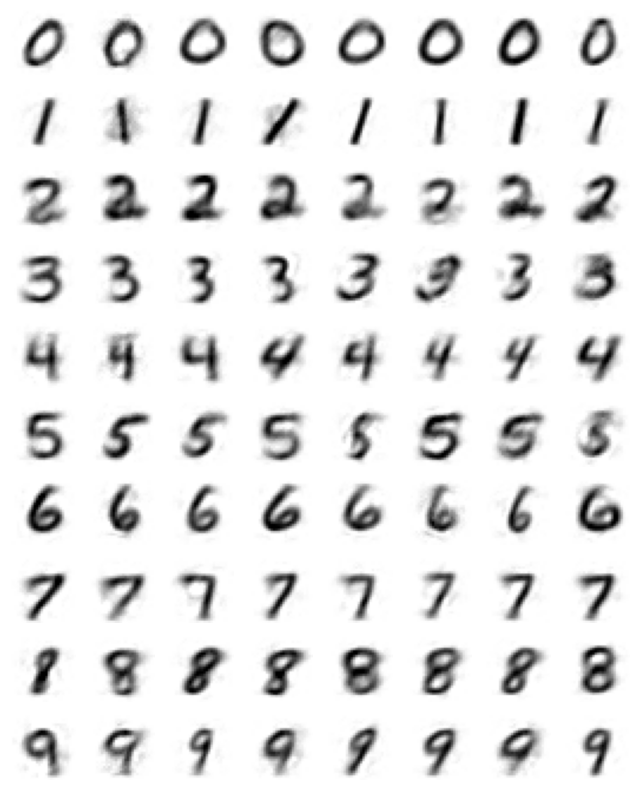

In [52]:
#### Plot outputs of autoencoder:
#########
fig1, ax1 = plt.subplots(10, 8, figsize=(8,10))

#ax1=ax1.flatten()


class_vae.eval()

#Generate 8 examples of each class
for y_val in range(10):
    for i in range(8):

        y = torch.tensor(y_val)
        with torch.no_grad():
            Z = torch.randn(z_dim)
            y_one_hot = torch.nn.functional.one_hot(y, 10)
            Z = torch.cat((Z, y_one_hot), axis=-1)

            image = class_vae.decoder(Z.to(device)).view(1,28,28).cpu()

        #Can clip to 0, 1:
        image = np.clip(image, 0, 1)

        ax1[y_val, i].imshow(image.permute(1,2,0), cmap='gray_r')
        ax1[y_val, i].set_axis_off()

## Do a convolutional version:



In [53]:
#Encoder:
#######

class VAEConvEncoder(nn.Module):
    def __init__(self, in_dim, num_classes, z_dim):

        super().__init__()

        #Each class has an input channel
        self.conv1 = nn.Conv2d(in_dim + num_classes, 16, (3,3), stride=1, padding='same')
        self.bn1 = nn.BatchNorm2d(16)
        self.pool1 = nn.MaxPool2d(2, 2) #Will reduce size to 14x14

        self.conv2 = nn.Conv2d(16, 32, (3,3), stride=1, padding='same')
        self.bn2 = nn.BatchNorm2d(32)
        self.pool2 = nn.MaxPool2d(2, 2) #Reduce size to 7x7

        self.conv3 = nn.Conv2d(32, 64, (3,3), stride=1, padding='same')
        self.bn3 = nn.BatchNorm2d(64)
        self.pool3 = nn.MaxPool2d(2, 2) #Reduce to 3x3

        self.linear = nn.Linear(3*3*64, z_dim*2)


        self.relu = nn.ReLU()


    def forward(self, x):
        x = self.pool1(self.relu(self.bn1(self.conv1(x))))
        x = self.pool2(self.relu(self.bn2(self.conv2(x))))
        x = self.pool3(self.relu(self.bn3(self.conv3(x))))

        x = x.view(-1, 3*3*64)
        x = self.linear(x)


        return x


In [55]:
## And Decoder:
#####

class VAEConvDecoder(nn.Module):
    def __init__(self, z_dim, num_classes, out_dim):

        super().__init__()

        self.z_dim = z_dim
        self.num_classes = num_classes
        self.layer0 = nn.Linear(z_dim + num_classes, 3*3*64)

        self.convT1 = nn.ConvTranspose2d(64, 32, (3,3), stride=2, padding=0) #, output_padding=1)
        self.bn1 = nn.BatchNorm2d(32)

        self.convT2 = nn.ConvTranspose2d(32, 16, (3,3), stride=2, padding=1, output_padding=1)
        self.bn2 = nn.BatchNorm2d(16)

        self.convT3 = nn.ConvTranspose2d(16, 1, (3,3), stride=2, padding=1, output_padding=1)
        self.bn3 = nn.BatchNorm2d(1)

        self.sigmoid = nn.Sigmoid()
        self.relu = nn.ReLU()

    def forward(self, x):

        x = (self.layer0(x)).view(-1, 64, 3, 3)

        x = self.relu(self.bn1(self.convT1(x)))
        x = self.relu(self.bn2(self.convT2(x)))
        x = self.sigmoid(self.bn3(self.convT3(x)))

        return x

In [56]:
class ConvConditionalVAE(nn.Module):

    def __init__(self, input_dim, num_classes, z_dim):

        super().__init__()

        self.num_classes = num_classes

        #Create the encoder/decoder
        self.encoder = VAEConvEncoder(input_dim, num_classes, z_dim)
        self.decoder = VAEConvDecoder(z_dim, num_classes, input_dim)

    #z_mean = mean vector, z_gamma = logvar vector
    def get_z_sample(self, z_mean, z_gamma):

        #Draw from a standard normal
        epsilon = torch.randn_like(z_mean)

        #Standard deviation
        sigma = torch.exp(.5 * z_gamma)

        #Latent sample:
        Z = z_mean + epsilon * sigma
        return Z


    #Run the model in training mode:
    def forward(self, x, class_one_hot):

        #First encode:
        mu_gamma = self.encoder(x)

        #split and pass to get_z_sample:
        mu, gamma = mu_gamma.chunk(2, axis=-1)

        #Sample:
        z = self.get_z_sample(mu, gamma)

        #Add class one-hot vector
        z = torch.cat((z, class_one_hot), dim=-1)

        #Finally decode:
        x_out = self.decoder(z)

        #Return the x_out, mu, and gamma:
        return x_out, mu, gamma


In [57]:
## Convolutional conditional VAE
########

z_dim=32
conv_class_vae = ConvConditionalVAE(input_dim=1, num_classes=10, z_dim=z_dim)

conv_class_vae = conv_class_vae.to(device)

In [58]:
#Reconstruction loss Function:
recon_loss = nn.MSELoss()

#And Optimizer:
optimizer = torch.optim.Adam(conv_class_vae.parameters(), lr=0.001)

In [59]:
X_in, y = next(iter(train_loader))

X_in.shape

torch.Size([32, 1, 28, 28])

In [60]:
y_one_hot = torch.nn.functional.one_hot(y, 10)
y_map = y_one_hot.unsqueeze(-1).unsqueeze(-1).expand(32, 10, 28, 28)
X_in = torch.cat((X_in, y_map), dim=1)

X_in.shape

torch.Size([32, 11, 28, 28])

In [73]:
#Quick check:
y_one_hot[0]

tensor([0, 0, 1, 0, 0, 0, 0, 0, 0, 0])

In [76]:
#And:
y_map[0,2,:,:]

tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
         1, 1, 1, 1],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
         1, 1, 1, 1],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
         1, 1, 1, 1],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
         1, 1, 1, 1],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
         1, 1, 1, 1],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
         1, 1, 1, 1],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
         1, 1, 1, 1],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
         1, 1, 1, 1],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
         1, 1, 1, 1],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1

In [77]:
## Run the training loop for a number of epochs
loss_list = []

vae.train()

for epoch in range(1):

    for batch in train_loader:
        #Unpack to X and y
        X_in, y = batch

        X_in = X_in.to(device)
        y = y.to(device)

        y_one_hot = torch.nn.functional.one_hot(y, 10)

        y_map = y_one_hot.unsqueeze(-1).unsqueeze(-1).expand(X_in.shape[0], 10, 28, 28).to(device)
        X_in = torch.cat((X_in, y_map), dim=1)


        #Train on our input:
        X_out, mu, gamma = conv_class_vae(X_in, y_one_hot)

        #Loss:
        #Combo of KL divergence and MSE:
        sigma2 = torch.exp(gamma) #gamma = log(sigma2) so just use gamma in one term below:

        KL_loss = torch.mean(-.5 * torch.sum(1 + gamma - sigma2 - mu**2, axis=-1))

        loss = recon_loss(X_out, X_in[:,[0],:,:]) + 1 * KL_loss / 784

        #Backprop
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        loss_list.append(loss.item())

    print(epoch)
    print(loss.item())

0
0.05162705108523369


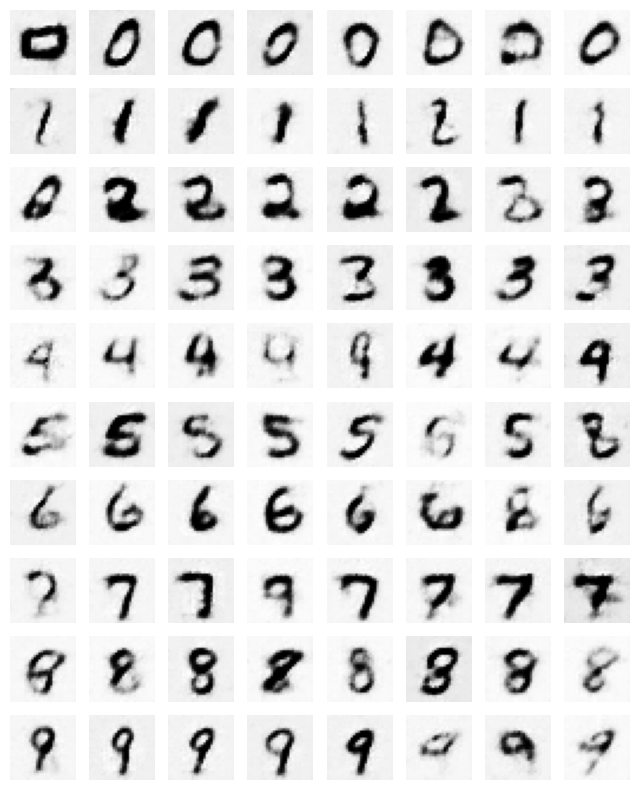

In [78]:
#### Plot outputs of autoencoder:
#########
fig1, ax1 = plt.subplots(10, 8, figsize=(8,10))

#ax1=ax1.flatten()

#And plot:
for y_val in range(10):
    for i in range(8):

        #And reconstruction:
        conv_class_vae.eval()

        y = torch.tensor(y_val)
        with torch.no_grad():
            Z = torch.randn(z_dim)
            y_one_hot = torch.nn.functional.one_hot(y, 10)
            Z = torch.cat((Z, y_one_hot), axis=-1)

            image = conv_class_vae.decoder(Z.to(device)).view(1,28,28).cpu()

        #Can clip to 0, 1:
        image = np.clip(image, 0, 1)

        ax1[y_val, i].imshow(image.permute(1,2,0), cmap='gray_r')
        ax1[y_val, i].set_axis_off()